# Lab 2

## Data Cleaning Challenge Assignment
### Objective: Clean and prepare a messy dataset for use in an AI project
You have received a new dataset – but this time, it’s in CSV format instead of JSON. The structure is slightly different from what we used in class, and the dataset contains various issues. Your task is to apply your knowledge to:
- Understand and analyze the data
- Identify and fix problems in the dataset
- Make decisions on how to handle them
- Prepare the dataset so it can be used in an AI model


 

In [1080]:
import pandas as pd
import numpy as np

### 1. Load the CSV file (`messy_data.csv`) into a pandas DataFrame.


In [1081]:
df = pd.read_csv('./data/messy_data.csv')

### 2. Explore the data:
- What values are missing?
    - some values in
        - age - should be replaced with average
        - height - should be replaced with average
        - income - should be replaced with average
        - purchases - 
        - gender - should not be replaced as it would skew the distribution too much (large percentage is unknown)
- Are there any unrealistic values? (e.g., age = 150, height = -99) 
    - age = 150
    - height = -99
    - gender = unknown
- Are there format or type issues that need fixing?
    - purchases are in quote signs, should be a list (?)

In [1082]:
df

,id,age,height,weight,income,purchases,gender
0,1,25.0,175.0,68,35000.0,"23,45,12",male
1,2,NaN,182.0,80,42000.0,"34,,19",female
2,3,150.0,165.0,180,28000.0,NaN,unknown
3,4,34.0,168.0,70,NaN,",55,67",male
4,5,29.0,190.0,165,31000.0,"12,19,23",female
5,6,42.0,NaN,82,37000.0,"40,41,42",male
6,7,NaN,-99.0,190,NaN,"23,,",female
7,8,38.0,172.0,75,39000.0,"22,20",unknown
8,9,44.0,180.0,160,41000.0,NaN,male
9,10,33.0,160.0,130,0.0,"14,13,12",other


### 3. Clean the data step-by-step:

- Identify and process outliers (you define the thresholds)
- Ensure all height values are valid (e.g., no negatives)

In [1083]:
max_age = df['age'].nlargest(2).min()
min_height = df['height'].nsmallest(2).max()
df['age'] = df['age'].apply(lambda x: min(x, max_age))
df['height'] = df['height'].apply(lambda x: max(x, min_height))
df

,id,age,height,weight,income,purchases,gender
0,1,25.0,175.0,68,35000.0,"23,45,12",male
1,2,NaN,182.0,80,42000.0,"34,,19",female
2,3,44.0,165.0,180,28000.0,NaN,unknown
3,4,34.0,168.0,70,NaN,",55,67",male
4,5,29.0,190.0,165,31000.0,"12,19,23",female
5,6,42.0,NaN,82,37000.0,"40,41,42",male
6,7,NaN,160.0,190,NaN,"23,,",female
7,8,38.0,172.0,75,39000.0,"22,20",unknown
8,9,44.0,180.0,160,41000.0,NaN,male
9,10,33.0,160.0,130,0.0,"14,13,12",other


- Handle missing values (you decide how)

In [1084]:
average_age = df['age'].mean()
average_height = df['height'].mean()
average_income = df['income'].mean()
df['age'] = df['age'].fillna(round(average_age))
df['height'] = df['height'].fillna(round(average_height))
df['income'] = df['income'].fillna(round(average_income))
print(df)

   id   age  height  weight   income purchases   gender
0   1  25.0   175.0      68  35000.0  23,45,12     male
1   2  36.0   182.0      80  42000.0    34,,19   female
2   3  44.0   165.0     180  28000.0       NaN  unknown
3   4  34.0   168.0      70  31625.0    ,55,67     male
4   5  29.0   190.0     165  31000.0  12,19,23   female
5   6  42.0   172.0      82  37000.0  40,41,42     male
6   7  36.0   160.0     190  31625.0      23,,   female
7   8  38.0   172.0      75  39000.0     22,20  unknown
8   9  44.0   180.0     160  41000.0       NaN     male
9  10  33.0   160.0     130      0.0  14,13,12    other


- Normalize relevant numerical columns (e.g., height, weight, income)

In [1085]:
max_height = df['height'].max()
max_height = max_height if max_height !=0 else 1
max_weight = df['weight'].max()
max_weight = max_weight if max_weight !=0 else 1
max_income = df['income'].max()
max_income = max_income if max_income !=0 else 1
df['height'] = df['height'] / max_height
df['weight'] = df['weight'] / max_weight
df['income'] = df['income'] / max_income
df


,id,age,height,weight,income,purchases,gender
0,1,25.0,0.921053,0.357895,0.833333,"23,45,12",male
1,2,36.0,0.957895,0.421053,1.000000,"34,,19",female
2,3,44.0,0.868421,0.947368,0.666667,NaN,unknown
3,4,34.0,0.884211,0.368421,0.752976,",55,67",male
4,5,29.0,1.000000,0.868421,0.738095,"12,19,23",female
5,6,42.0,0.905263,0.431579,0.880952,"40,41,42",male
6,7,36.0,0.842105,1.000000,0.752976,"23,,",female
7,8,38.0,0.905263,0.394737,0.928571,"22,20",unknown
8,9,44.0,0.947368,0.842105,0.976190,NaN,male
9,10,33.0,0.842105,0.684211,0.000000,"14,13,12",other


- Convert categorical values to numerical format using one-hot encoding

In [1086]:
df = pd.get_dummies(df, prefix='gender', columns=['gender'])
df

,id,age,height,weight,income,purchases,gender_female,gender_male,gender_other,gender_unknown
0,1,25.0,0.921053,0.357895,0.833333,"23,45,12",False,True,False,False
1,2,36.0,0.957895,0.421053,1.000000,"34,,19",True,False,False,False
2,3,44.0,0.868421,0.947368,0.666667,NaN,False,False,False,True
3,4,34.0,0.884211,0.368421,0.752976,",55,67",False,True,False,False
4,5,29.0,1.000000,0.868421,0.738095,"12,19,23",True,False,False,False
5,6,42.0,0.905263,0.431579,0.880952,"40,41,42",False,True,False,False
6,7,36.0,0.842105,1.000000,0.752976,"23,,",True,False,False,False
7,8,38.0,0.905263,0.394737,0.928571,"22,20",False,False,False,True
8,9,44.0,0.947368,0.842105,0.976190,NaN,False,True,False,False
9,10,33.0,0.842105,0.684211,0.000000,"14,13,12",False,False,True,False


### 4. Convert the `purchases` column:
- This column is a string – convert it into a list of numbers
- Replace missing values inside the list (e.g., empty strings) with 0

In [1087]:
def clean_purchases(purchases):
    if pd.isna(purchases) or purchases == '':
        return []
    
    purchases_list = []
    for purchase in purchases.split(','):
        purchase = purchase.strip()
        if purchase == '' or not purchase.isdigit():
            purchases_list.append(0)
        else:
            purchases_list.append(int(purchase))
    
    return purchases_list

df['purchases'] = df['purchases'].apply(clean_purchases)
df

,id,age,height,weight,income,purchases,gender_female,gender_male,gender_other,gender_unknown
0,1,25.0,0.921053,0.357895,0.833333,"[23, 45, 12]",False,True,False,False
1,2,36.0,0.957895,0.421053,1.000000,"[34, 0, 19]",True,False,False,False
2,3,44.0,0.868421,0.947368,0.666667,[],False,False,False,True
3,4,34.0,0.884211,0.368421,0.752976,"[0, 55, 67]",False,True,False,False
4,5,29.0,1.000000,0.868421,0.738095,"[12, 19, 23]",True,False,False,False
5,6,42.0,0.905263,0.431579,0.880952,"[40, 41, 42]",False,True,False,False
6,7,36.0,0.842105,1.000000,0.752976,"[23, 0, 0]",True,False,False,False
7,8,38.0,0.905263,0.394737,0.928571,"[22, 20]",False,False,False,True
8,9,44.0,0.947368,0.842105,0.976190,[],False,True,False,False
9,10,33.0,0.842105,0.684211,0.000000,"[14, 13, 12]",False,False,True,False


### 5. Save your cleaned DataFrame as a new CSV file (`cleaned_data.csv`).


In [1088]:
df.to_csv('./data/cleaned_data.csv')

### 🏆 Optional Challenge
If you finish early, try adding:

- A plot showing the distribution of age, income, or number of purchases

In [1089]:
import matplotlib.pyplot as plt

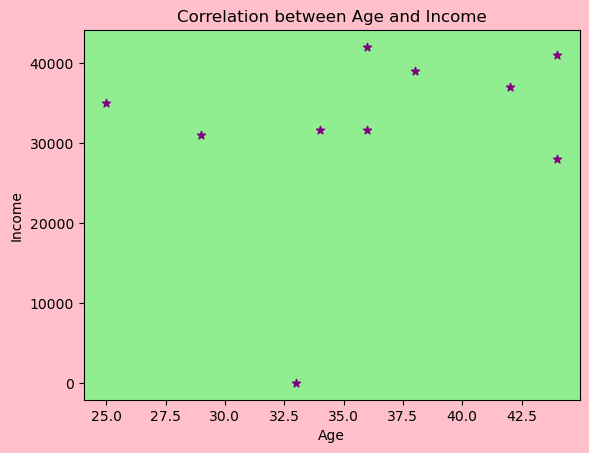

In [1090]:

fig = plt.figure()
fig.patch.set_facecolor('pink')
ax = plt.axes()
ax.patch.set_facecolor('lightgreen')

plt.scatter(df['age'], (df['income'] * max_income), color='purple', marker='*')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Correlation between Age and Income')
plt.show()

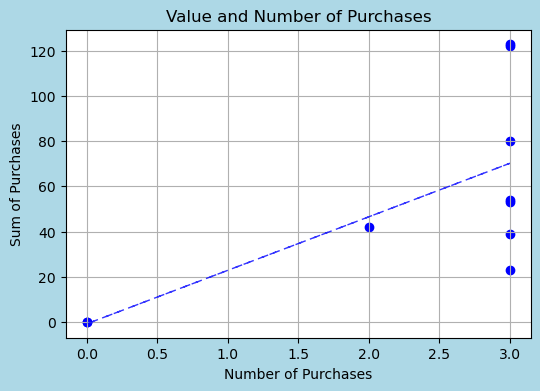

In [1091]:
fig = plt.figure(figsize=(6,4))
fig.patch.set_facecolor('lightblue')
number_purchases = df['purchases'].apply(len)
value_purchases = df['purchases'].apply(sum)
plt.scatter(number_purchases, value_purchases, marker = 'o',  color='blue')

z = np.polyfit(number_purchases, value_purchases, 1)
p = np.poly1d(z)
plt.plot(number_purchases, p(number_purchases), linestyle='dashed', color='blue', alpha=0.8, linewidth=1, dashes= [5,15])

plt.xlabel('Number of Purchases')
plt.ylabel('Sum of Purchases')
plt.title('Value and Number of Purchases')
plt.grid()
plt.show()

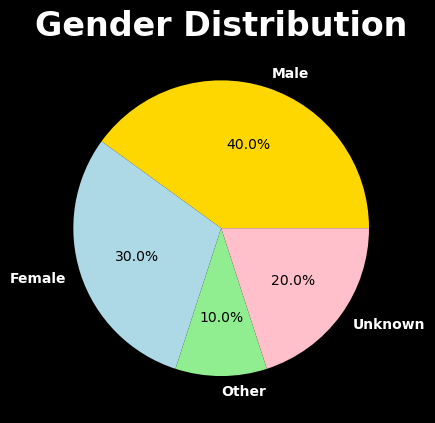

In [1092]:

gender_counts = [df['gender_male'].sum(), df['gender_female'].sum(), df['gender_other'].sum(), df['gender_unknown'].sum()]

fig = plt.figure()
fig.patch.set_facecolor('black')
wedges, texts, autotexts = plt.pie(gender_counts, labels=['Male','Female','Other','Unknown'], autopct='%1.1f%%', colors=['gold','lightblue','lightgreen','pink'])
for text in texts:
    text.set_color('white')
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_color('black')
    
plt.title('Gender Distribution', color='white', fontweight='bold', fontsize='24')
plt.show()

- A function that automatically detects outliers in a column

In [ ]:
average_weight = df['weight'].mean()

def detect_outliers(value, column_title):
    if pd.isna(value):
        continue

    match column_title:
        case 'age':
            if value < 18 or value > 65:
                df['age'] = df['age'].fillna(round(average_age))
        case 'height':
            if value < 80 or value > 230:
                df['height'] = df['height'].fillna(round(average_height))
        case 'weight':
            if value < 40 or value > 300:
                df['weight'] = df['weight'].fillna(round(average_weight))
        case 'income':
            if value < 0 or value > 500000:
                df['income'] = df['income'].fillna(round(average_income))    
    



    

df['age'] = df['age'].apply(detect_outliers, 'age')